In [13]:
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from calibration import lifetime_to_temperature_201112, lifetime_to_temperature_water
from scipy.optimize import curve_fit
from matplotlib.backends.backend_pdf import PdfPages
from scipy.stats import sem

In [14]:
files_path = glob.glob('./100mW/20111*_relaxation_whole_lin22.6_70msec_100mW_5sec/whole_cells/*.csv')
files_path.sort()

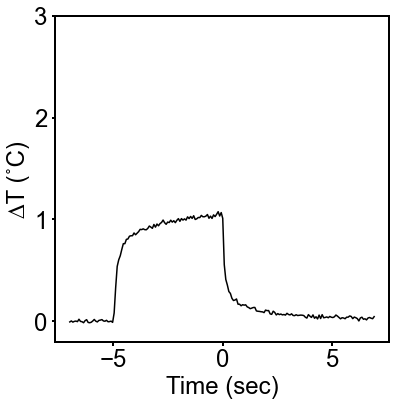

In [15]:
plt.figure(figsize = (6, 6))
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['xtick.major.width'] = 2.0
plt.rcParams['ytick.major.width'] = 2.0
plt.rcParams['axes.linewidth'] = 2.0
data_set_100mW = pd.DataFrame()

#データの平均化
average = np.zeros((1, 200))
for path in files_path:
    df = pd.read_csv(path, sep = '\t')
    relaxation_int = np.array(df.iloc[1:, 3], dtype = 'float32')
    relaxation = np.array(df.iloc[1:, 1], dtype = 'float32')
    diff = relaxation_int[:-1] - relaxation_int[1:]
    off_time = np.argmax(diff)
    extract = lifetime_to_temperature_201112(relaxation[off_time-100 : off_time+100])
    average += extract
    data_set_100mW = pd.concat([data_set_100mW, pd.DataFrame(extract)], axis = 1)
average_normal = average[0]/len(files_path)
average_normal = average_normal - np.mean(average_normal[:10])
time = [(i-100)*0.07 for i in range(len(average_normal))]
plt.tick_params(axis='both', direction = "out", labelsize = 24)
plt.plot(time, average_normal, color = 'Black')
plt.ylim(-0.2, 3.0)
plt.xlabel('Time (sec)', fontsize = 24)
plt.ylabel('∆T (˚C)', fontsize = 24)
plt.show()

#データの保存
(data_set_100mW - np.mean(data_set_100mW.iloc[:10, :])).to_csv('data_set_deltaT_100mW.csv')

In [16]:
files_path = glob.glob('./130mW/2106??_relaxation_26_whole/*.csv')
files_path.sort()

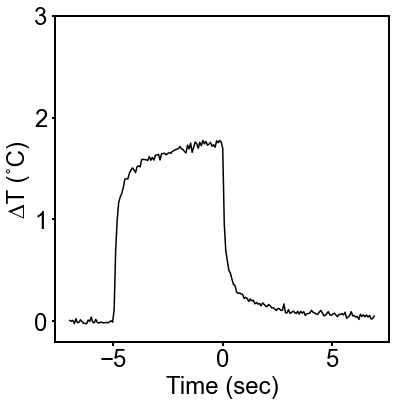

In [17]:
plt.figure(figsize = (6, 6))
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['xtick.major.width'] = 2.0
plt.rcParams['ytick.major.width'] = 2.0
plt.rcParams['axes.linewidth'] = 2.0
data_set_130mW = pd.DataFrame()

#データの平均化
average = np.zeros((1, 200))
for path in files_path:
    df = pd.read_csv(path, sep = '\t')
    relaxation_int = np.array(df.iloc[1:, 3], dtype = 'float32')
    relaxation = np.array(df.iloc[1:, 1], dtype = 'float32')
    diff = relaxation_int[:-1] - relaxation_int[1:]
    off_time = np.argmax(diff)
    extract = lifetime_to_temperature_201112(relaxation[off_time-100 : off_time+100])
    average += extract
    data_set_130mW = pd.concat([data_set_130mW, pd.DataFrame(extract)], axis = 1)
average_normal_130mW = average[0]/len(files_path)
average_normal_130mW = average_normal_130mW - np.mean(average_normal_130mW[:10])
time = [(i-100)*0.07 for i in range(len(average_normal_130mW))]
plt.tick_params(axis='both', direction = "out", labelsize = 24)
plt.plot(time, average_normal_130mW, color = 'Black')
plt.ylim(-0.2, 3.0)
plt.xlabel('Time (sec)', fontsize = 24)
plt.ylabel('∆T (˚C)', fontsize = 24)
plt.show()

#データの保存
(data_set_130mW - np.mean(data_set_130mW.iloc[:10, :])).to_csv('data_set_deltaT_130mW.csv')

In [18]:
files_path = glob.glob('./160mW/2106??_relaxation_26_whole/*.csv')
files_path.sort()

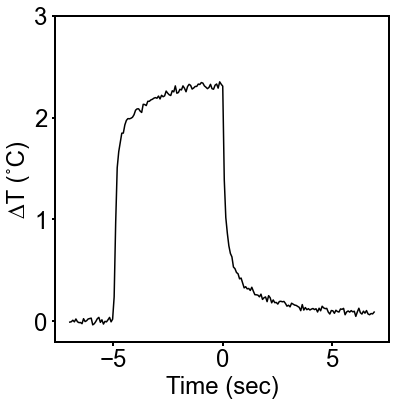

In [19]:
plt.figure(figsize = (6, 6))
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['xtick.major.width'] = 2.0
plt.rcParams['ytick.major.width'] = 2.0
plt.rcParams['axes.linewidth'] = 2.0
data_set_160mW = pd.DataFrame()

#データの平均化
average = np.zeros((1, 200))
for path in files_path:
    df = pd.read_csv(path, sep = '\t')
    relaxation_int = np.array(df.iloc[1:, 3], dtype = 'float32')
    relaxation = np.array(df.iloc[1:, 1], dtype = 'float32')
    diff = relaxation_int[:-1] - relaxation_int[1:]
    off_time = np.argmax(diff)
    extract = lifetime_to_temperature_201112(relaxation[off_time-100 : off_time+100])
    average += extract
    data_set_160mW = pd.concat([data_set_160mW, pd.DataFrame(extract)], axis = 1)
average_normal_160mW = average[0]/len(files_path)
average_normal_160mW = average_normal_160mW - np.mean(average_normal_160mW[:10])
time = [(i-100)*0.07 for i in range(len(average_normal_160mW))]
plt.tick_params(axis='both', direction = "out", labelsize = 24)
plt.plot(time, average_normal_160mW, color = 'Black')
plt.ylim(-0.2, 3.0)
plt.xlabel('Time (sec)', fontsize = 24)
plt.ylabel('∆T (˚C)', fontsize = 24)
plt.show()

#データの保存
(data_set_160mW - np.mean(data_set_160mW.iloc[:10, :])).to_csv('data_set_deltaT_160mW.csv')

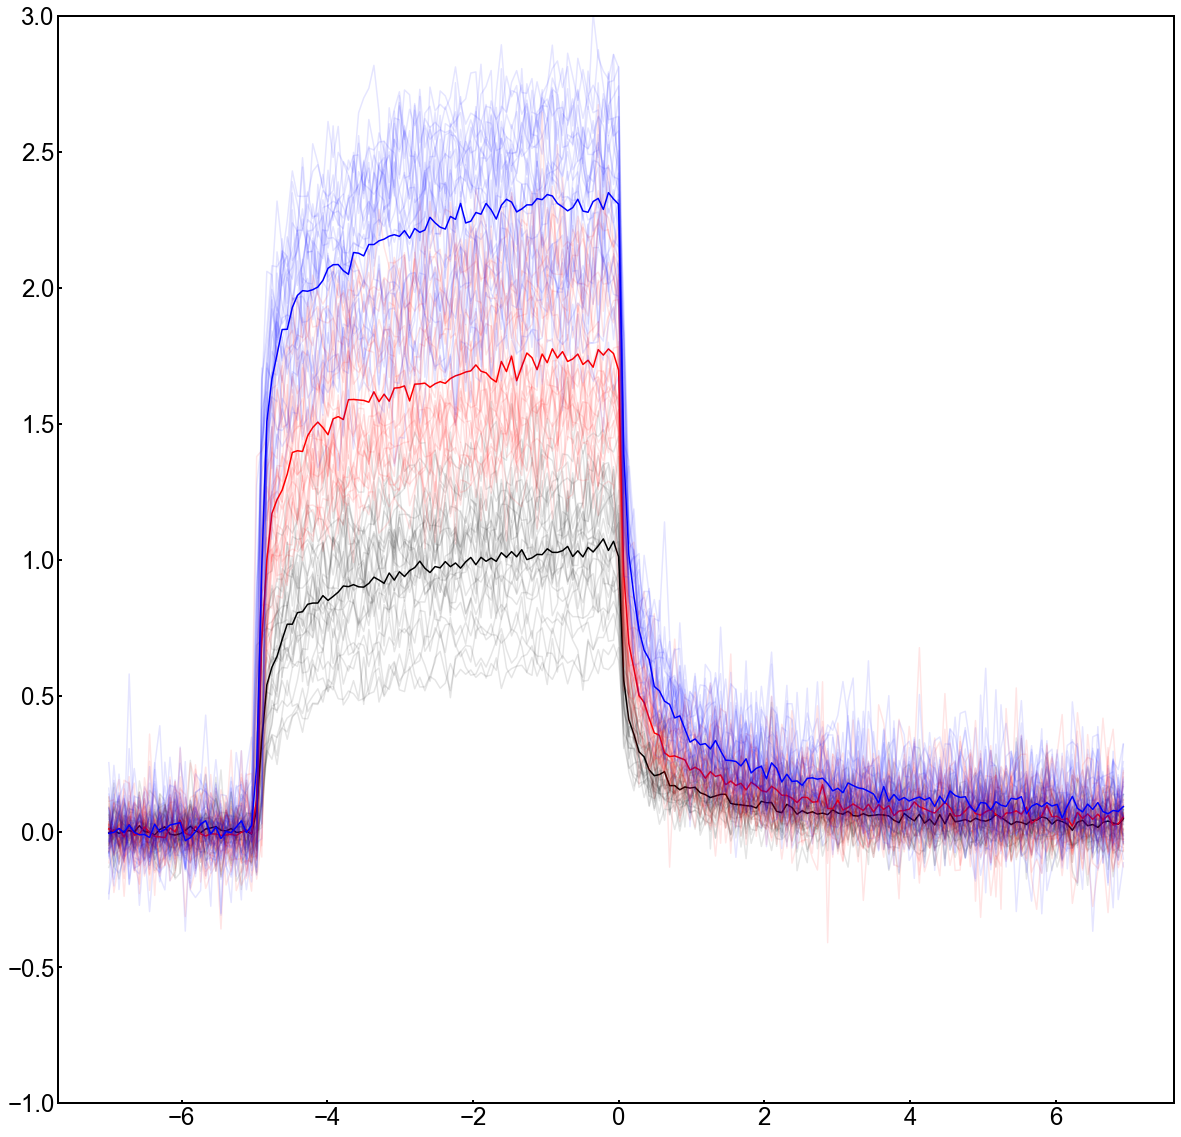

In [20]:
fig = plt.figure(figsize = (20, 20))
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['xtick.major.width'] = 2.0
plt.rcParams['ytick.major.width'] = 2.0
plt.rcParams['axes.linewidth'] = 2.0
plt.tick_params(axis='both', direction = "in", labelsize = 24)

time = [0.07*(i-100) for i in range(len(average_normal))]

plt.plot(time, average_normal, color = 'black')
plt.plot(time, data_set_100mW - np.mean(data_set_100mW.iloc[:10, :]), color = 'black', alpha = 0.1)
plt.plot(time, average_normal_130mW, color = 'red')
plt.plot(time, data_set_130mW - np.mean(data_set_130mW.iloc[:10, :]), color = 'red', alpha = 0.1)
plt.plot(time, average_normal_160mW, color = 'blue')
plt.plot(time, data_set_160mW - np.mean(data_set_160mW.iloc[:10, :]), color = 'blue', alpha = 0.1)
plt.ylim(-1, 3)
plt.show()


#pdfのセーブ
pp = PdfPages('./FigS10_outline.pdf')
pp.savefig(fig)
pp.close()

#データの保存
pd.DataFrame(average_normal).to_csv('ave_100mW_deltaT.csv')
pd.DataFrame(average_normal).to_csv('ave_130mW_deltaT.csv')
pd.DataFrame(average_normal).to_csv('ave_160mW_deltaT.csv')

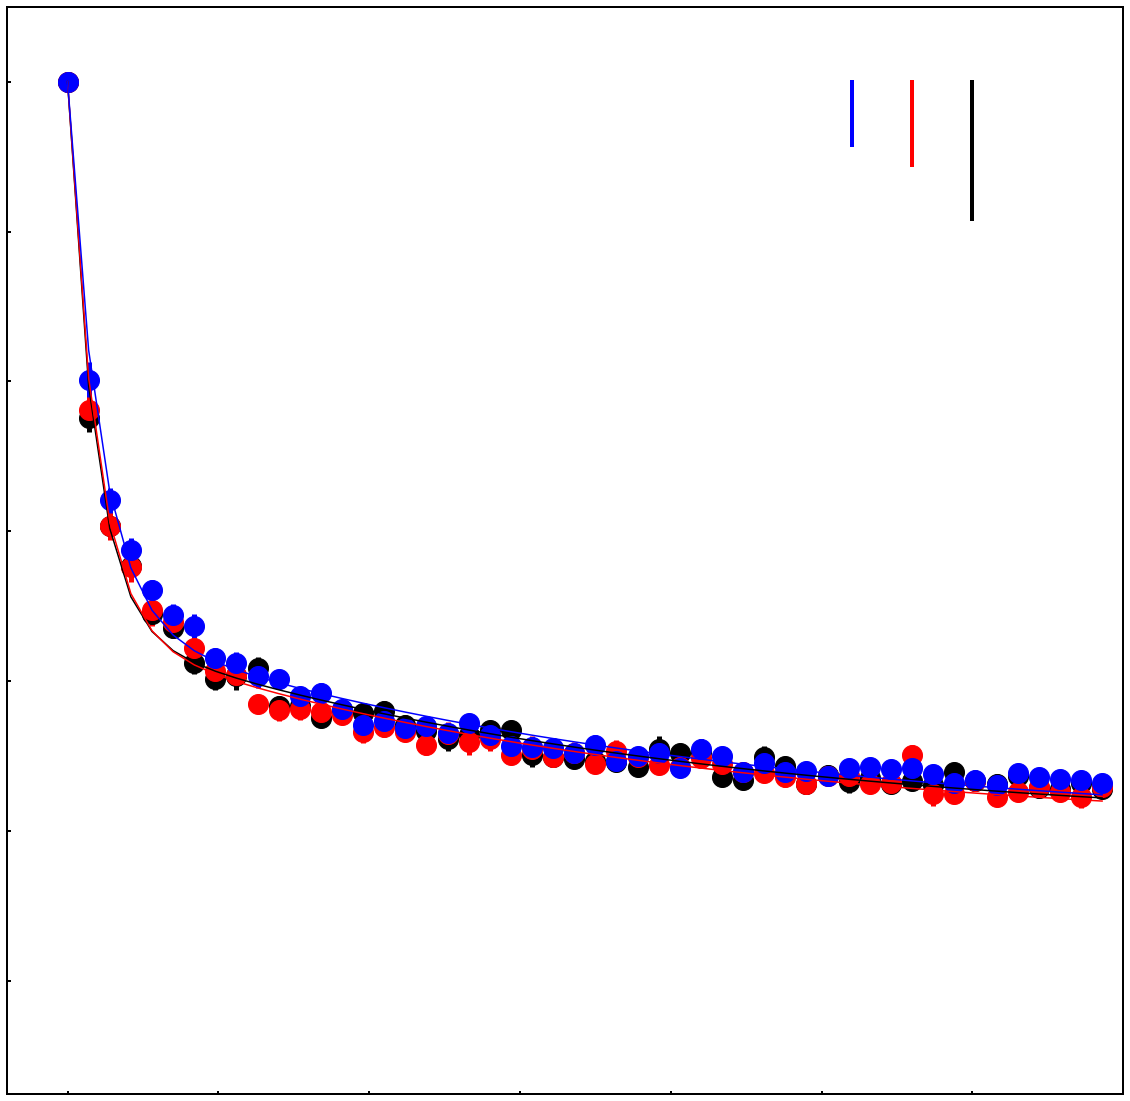

In [21]:
#実測データのプロット
fig = plt.figure(figsize = (20, 20))
plt.tick_params(axis='both', direction = "in", labelsize = 24)
time_normal = [(i)*0.07 for i in range(len(average_normal[100:150]))]


#SEMの計算
data_set_100mW = data_set_100mW - np.mean(data_set_100mW.iloc[:10, :])
data_set_100mW = data_set_100mW/data_set_100mW.iloc[100, :]*100
sem_100mW = data_set_100mW.sem(axis = 1)
sem_100mW[100] = 0

data_set_130mW = data_set_130mW - np.mean(data_set_130mW.iloc[:10, :])
data_set_130mW = data_set_130mW/data_set_130mW.iloc[100, :]*100
sem_130mW = data_set_130mW.sem(axis = 1)
sem_130mW[100] = 0

data_set_160mW = data_set_160mW - np.mean(data_set_160mW.iloc[:10, :])
data_set_160mW = data_set_160mW/data_set_160mW.iloc[100, :]*100
sem_160mW = data_set_160mW.sem(axis = 1)
sem_160mW[100] = 0

#1˚Cを示すバーを挿入
normal_bar = [100 - 20/max(average_normal)*i/100 for i in range(100)]
normal_bar_pos = [3.0 for i in range(len(normal_bar))]
plt.plot(normal_bar_pos, normal_bar, linewidth = 4, color = 'black', linestyle = '-')

bar_130mW = [100 - 20/max(average_normal_130mW)*i/100 for i in range(100)]
bar_130mW_pos = [2.8 for i in range(len(bar_130mW))]
plt.plot(bar_130mW_pos, bar_130mW, linewidth = 4, color = 'red', linestyle = '-')

bar_160mW = [100 - 20/max(average_normal_160mW)*i/100 for i in range(100)]
bar_160mW_pos = [2.6 for i in range(len(bar_160mW))]
plt.plot(bar_160mW_pos, bar_160mW, linewidth = 4, color = 'blue', linestyle = '-')

plt.errorbar(time_normal, average_normal[100:150]*100/average_normal[100], yerr = np.ravel(sem_100mW)[100:150], capsize=0, fmt='o', markersize=0, linewidth = 5, ecolor='black')
plt.plot(time_normal, average_normal[100:150]*100/average_normal[100], color = 'black', markersize = 20, marker = 'o', linewidth = 0)

plt.errorbar(time_normal, average_normal_130mW[100:150]*100/average_normal_130mW[100], yerr = np.ravel(sem_130mW)[100:150], capsize=0, fmt='o', markersize=0, linewidth = 5, ecolor='red')
plt.plot(time_normal, average_normal_130mW[100:150]*100/average_normal_130mW[100], color = 'red', markersize = 20, marker = 'o', linewidth = 0)

plt.errorbar(time_normal, average_normal_160mW[100:150]*100/average_normal_160mW[100], yerr = np.ravel(sem_160mW)[100:150], capsize=0, fmt='o', markersize=0, linewidth = 5, ecolor='blue')
plt.plot(time_normal, average_normal_160mW[100:150]*100/average_normal_160mW[100], color = 'blue', markersize = 20, marker = 'o', linewidth = 0)

plt.tick_params(labelbottom=False,
                labelleft=False,
                labelright=False,
                labeltop=False)



#温度緩和の時定数の計算
def relaxation(time, ratio, t1, t2):
    return ratio*np.exp(-time/t1) + (1-ratio)*np.exp(-time/t2)
result_100mW = curve_fit(relaxation, time_normal, average_normal[100:150]/average_normal[100])[0]
result_130mW = curve_fit(relaxation, time_normal, average_normal_130mW[100:150]/average_normal_130mW[100])[0]
result_160mW = curve_fit(relaxation, time_normal, average_normal_160mW[100:150]/average_normal_160mW[100])[0]


plt.xlim(-0.2, 3.5)
plt.ylim(-35, 110)

#fitting結果の図示
plt.plot(time_normal, relaxation(np.ravel(time_normal), result_100mW[0], result_100mW[1], result_100mW[2])*100, color = 'black')
plt.plot(time_normal, relaxation(np.ravel(time_normal), result_130mW[0], result_130mW[1], result_130mW[2])*100, color = 'red')
plt.plot(time_normal, relaxation(np.ravel(time_normal), result_160mW[0], result_160mW[1], result_160mW[2])*100, color = 'blue')


#pdfのセーブ
pp = PdfPages('./FigS10_ralaxation.pdf')
pp.savefig(fig)
pp.close()


#データの保存
pd.DataFrame(average_normal[100:150]*100/average_normal[100]).to_csv('ave_100mW.csv')
pd.DataFrame(average_normal_130mW[100:150]*100/average_normal_130mW[100]).to_csv('ave_130mW.csv')
pd.DataFrame(average_normal_160mW[100:150]*100/average_normal_160mW[100]).to_csv('ave_160mW.csv')
(sem_100mW)[100:150].to_csv('sem_100mW.csv')
(sem_130mW)[100:150].to_csv('sem_130mW.csv')
(sem_160mW)[100:150].to_csv('sem_160mW.csv')

In [22]:
sum_100mW = data_set_100mW.iloc[102:150].sum().values
sum_130mW = data_set_130mW.iloc[102:150].sum().values
sum_160mW = data_set_160mW.iloc[102:150].sum().values

In [23]:
sem_100mW_bar = (sum_100mW*0.07).std(ddof = 1)/np.sqrt(len(sum_100mW))
sem_130mW_bar = (sum_130mW*0.07).std(ddof = 1)/np.sqrt(len(sum_130mW))
sem_160mW_bar = (sum_160mW*0.07).std(ddof = 1)/np.sqrt(len(sum_160mW))

43.32829
1.9171741679965841
42.82548
2.5183748058049984
47.231014
2.3251051772807245


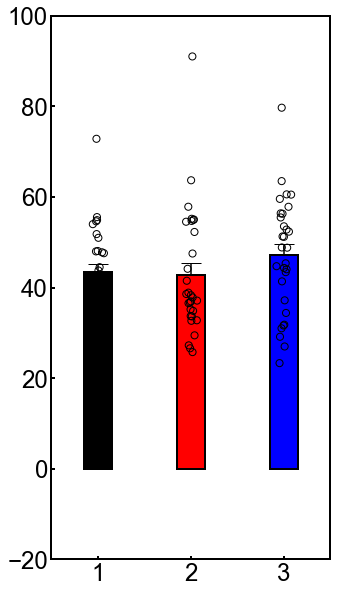

In [24]:
fig = plt.figure(figsize = (5, 10))
plt.tick_params(axis='both', direction = "in", labelsize = 24)
sum_100mW_ave = np.average(sum_100mW*0.07)
sum_130mW_ave = np.average(sum_130mW*0.07)
sum_160mW_ave = np.average(sum_160mW*0.07)

plt.bar(1, sum_100mW_ave, yerr = [[0], [sem_100mW_bar]], capsize = 10, ecolor = 'black', width=0.3, color=(0, 0, 0, 1), edgecolor='black', linewidth = 2, zorder = 1)
x = np.random.normal(1, 0.03, size=len(sum_100mW)) 
plt.scatter(x, sum_100mW*0.07, color='none', edgecolor='black', alpha = 1, s=50, zorder = 2)

plt.bar(2, sum_130mW_ave, yerr = [[0], [sem_130mW_bar]], capsize = 10, ecolor = 'black', width=0.3, color=(1, 0, 0, 1), edgecolor='black', linewidth = 2, zorder = 1)
x = np.random.normal(2, 0.03, size=len(sum_130mW)) 
plt.scatter(x, sum_130mW*0.07, color='none', edgecolor='black', alpha = 1, s=50, zorder = 2)

plt.bar(3, sum_160mW_ave, yerr = [[0], [sem_160mW_bar]], capsize = 10, ecolor = 'black', width=0.3, color=(0, 0, 1, 1), edgecolor='black', linewidth = 2, zorder = 1)
x = np.random.normal(3, 0.03, size=len(sum_160mW)) 
plt.scatter(x, sum_160mW*0.07, color='none', edgecolor='black', alpha = 1, s=50, zorder = 2)

plt.ylim(-20, 100)
plt.xlim(0.5, 3.5)

#pdfのセーブ
pp = PdfPages('./FigS10_ralaxation_bar.pdf')
pp.savefig(fig)
pp.close()

#データのセーブ
pd.DataFrame(sum_100mW*0.07).to_csv('AUC_100mW.csv')
pd.DataFrame(sum_130mW*0.07).to_csv('AUC_130mW.csv')
pd.DataFrame(sum_160mW*0.07).to_csv('AUC_160mW.csv')
print(sum_100mW_ave)
print(sem_100mW_bar)
print(sum_130mW_ave)
print(sem_130mW_bar)
print(sum_160mW_ave)
print(sem_160mW_bar)